## Frequency Modulation


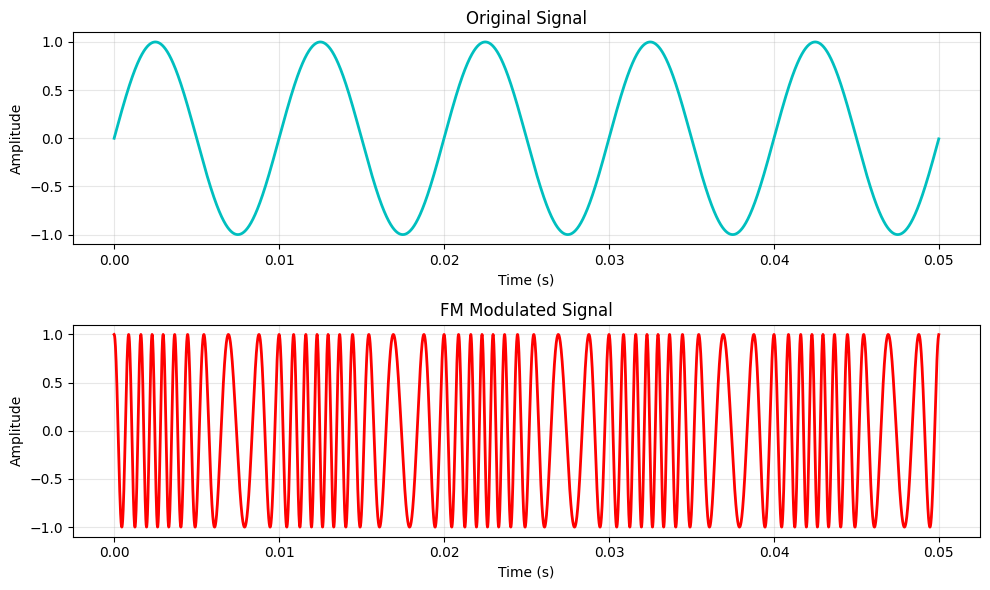

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Defining Parameters
fs = 100_000

Ac = 1
Am = 1

fm = 100
fc = 1000

kf = 500

t = np.arange(0, 0.05, 1 / fs)

# Message signal
message = Am * np.sin(2 * np.pi * fm * t)

# Carrier signal
carrier = Ac * np.cos(2 * np.pi * fc * t)

# FM Modulation
phase = 2 * np.pi * fc * t + 2 * np.pi * kf * np.cumsum(message) / fs
fm_signal = Ac * np.cos(phase)

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, message, "c", label="Original Signal", linewidth=2)
plt.title("Original Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t, fm_signal, "r", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("FM Modulated Signal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Adding Noise to Modulated Signal


Measured SNR (dB): 19.978681931735036


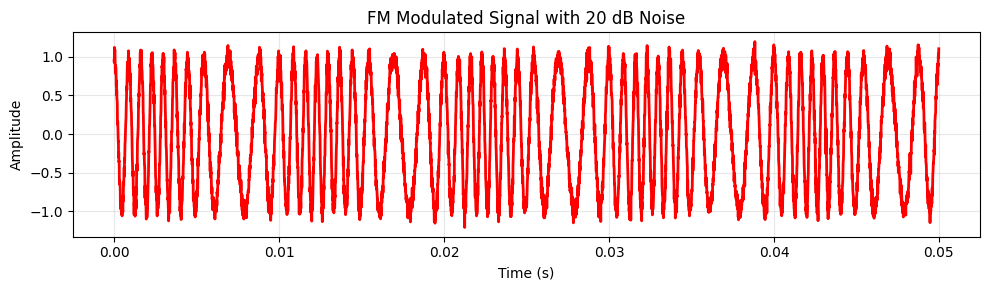

In [ ]:
# Add 20 dB noise
snr_db = 20
signal_power = np.mean(fm_signal**2)
noise_power = signal_power / (10 ** (snr_db / 10))
noise_std = np.sqrt(noise_power)
noise = np.random.normal(0, noise_std, fm_signal.shape)
fm_signal_noisy = fm_signal + noise

# Modulated signal with noise
plt.figure(figsize=(10, 3))
plt.plot(t, fm_signal_noisy, "r", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("FM Modulated Signal with 20 dB Noise")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Demodulating the Noisy Signal


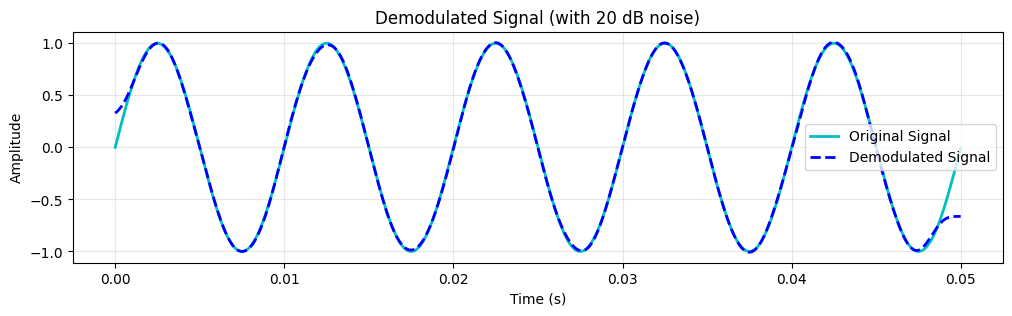

In [65]:
from scipy.signal import hilbert, butter, filtfilt

# Pass the Signal through Limiter to remove noise
y_limited = np.sign(fm_signal_noisy)

analytic_signal = hilbert(y_limited)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
# diff gives difference so we divide by delta time, i.e. multiply by fs
instantaneous_freq = np.diff(instantaneous_phase) * fs / (2 * np.pi)
instantaneous_freq = np.pad(
    instantaneous_freq, (1, 0), mode="edge"
)  # pad to match original signal length

recovered = (instantaneous_freq - fc) / kf

msg_cutoff = 400  # keep above message frequency
b, a = butter(5, msg_cutoff / (fs / 2), btype="low")
z_filtered = filtfilt(b, a, recovered)

# Demodulated signal
plt.figure(figsize=(12, 3))
plt.plot(t, message, "c", label="Original Signal", linewidth=2)
plt.plot(t, z_filtered, "b--", label="Demodulated Signal", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Demodulated Signal (with 20 dB noise)")
plt.legend()
plt.grid(True, alpha=0.3)

The code demonstrates **Frequency Modulation (FM)** and **demodulation** of a two-tone message signal. Here's what's happening:

### **1. Signal Generation**

- **Message signal**: A sum of two sine waves (30 Hz and 60 Hz) with amplitudes 1 and 2 respectively.
- **Carrier signal**: A high-frequency sine wave (200 Hz) used to "carry" the message.
- **FM modulation**: The message signal modulates the _frequency_ of the carrier. The instantaneous frequency varies based on the message amplitude.

### **2. FM Modulation**

- The phase of the carrier is modulated by integrating the message signal.
- The modulated signal `y` is:  
  $ y(t) = \cos(2\pi f*c t + 2\pi f*{\text{Dev}} \int x(t) dt) $

### **3. FM Demodulation**

- The **Hilbert transform** is used to extract the **instantaneous phase** of the modulated signal.
- The **instantaneous frequency** is obtained by differentiating the phase.
- The demodulated signal `z` is derived by subtracting the carrier frequency and normalizing by the frequency deviation.

### **Key Observations**

- The **modulated signal** (`y`) appears as a high-frequency oscillation whose frequency varies with the message signal.
- The **demodulated signal** (`z`) should closely resemble the original message (`x`).
- The **Hilbert transform** is crucial for extracting the envelope and phase in FM demodulation.

This is a classic example of **analog FM communication**.


The Hilbert transform is used for FM demodulation because it allows us to extract the **instantaneous phase** of a signal, which is essential for recovering the original message from frequency-modulated (FM) signals.

### **Why the Hilbert Transform?**

1. **Analytic Signal**: The Hilbert transform creates an **analytic signal** from a real-valued signal. For a modulated signal $ y(t) $, the analytic signal is:

   $$
   z(t) = y(t) + j \cdot \mathcal{H}\{y(t)\}
   $$

   where $ \mathcal{H}\{y(t)\} $ is the Hilbert transform of $ y(t) $.

2. **Instantaneous Phase**: The **phase** of the analytic signal is:

   $$
   \phi(t) = \arg(z(t)) = \angle(z(t))
   $$

   This phase contains the **frequency modulation** information.

3. **Instantaneous Frequency**: By differentiating the phase, we get the **instantaneous frequency**:

   $$
   f_{\text{inst}}(t) = \frac{1}{2\pi} \frac{d\phi(t)}{dt}
   $$

   For FM, the instantaneous frequency is:

   $$
   f_{\text{inst}}(t) = f_c + f_{\text{Dev}} \cdot x(t)
   $$

   where $ x(t) $ is the original message signal.

4. **Demodulation**: Subtract the carrier frequency $ f*c $ and divide by the frequency deviation $ f*{\text{Dev}} $ to recover $ x(t) $:
   $$
   \hat{x}(t) = \frac{f_{\text{inst}}(t) - f_c}{f_{\text{Dev}}}
   $$

### **Why Not Other Methods?**

- **Envelope Detection**: Works for AM, not FM.
- **Phase-Locked Loops (PLL)**: Can be used for FM demodulation but are more complex.
- **Frequency Discriminators**: Traditional analog methods, but the Hilbert transform is simpler and more accurate in digital systems.

### **Advantages of Hilbert Transform**

- **Simple**: Only requires computing the Hilbert transform and phase.
- **Accurate**: Works well even in noisy conditions.
- **Digital Implementation**: Easy to implement in software (e.g., `scipy.signal.hilbert`).

### **Example**

For a signal $ y(t) = \cos(2\pi f*c t + 2\pi f*{\text{Dev}} \int x(t) dt) $, the Hilbert transform helps recover $ x(t) $ by:

1. Computing the analytic signal $ z(t) $.
2. Extracting the phase $ \phi(t) $.
3. Differentiating to get instantaneous frequency.
4. Subtracting $ f*c $ and dividing by $ f*{\text{Dev}} $.

This method is widely used in **digital signal processing** for FM demodulation.
